# EN3160 Assignment 1 — Intensity Transformations and Neighborhood Filtering

**Name:** Maldniya.p.a.d.g.r.

**Index Number:** 230390A

**GitHub:** https://github.com/ransara3/image-processing-fundamentals.git



In [32]:
# Common imports used throughout the notebook
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Helper to show images side by side (handles BGR->RGB conversion automatically)
def show_images(images, titles, cmap=None, figsize=(12, 5)):
    n = len(images)
    fig, axes = plt.subplots(1, n, figsize=figsize)
    if n == 1:
        axes = [axes]
    for ax, im, title in zip(axes, images, titles):
        if im.ndim == 2:
            ax.imshow(im, cmap='gray' if cmap is None else cmap)
        else:
            ax.imshow(cv2.cvtColor(im, cv2.COLOR_BGR2RGB))
        ax.set_title(title)
        ax.axis('off')
    plt.tight_layout()
    plt.show()

## Question 1 — Piecewise-Linear Intensity Transformation

We implement `intensity_transform(im, breakpoints)` which builds a full 256-entry
lookup table (LUT) by **linearly interpolating between consecutive breakpoints**,
then applies it with `cv2.LUT`. This is much faster than looping pixel-by-pixel.

For a set of breakpoints `[(x0,y0), (x1,y1), ..., (xn,yn)]`, for every intensity
`x` between `x_{i}` and `x_{i+1}` we compute
`y = y_i + (y_{i+1}-y_i) * (x - x_i) / (x_{i+1} - x_i)`.



In [34]:
def intensity_transform(im, breakpoints):
    
    breakpoints = sorted(breakpoints, key=lambda p: p[0])
    xs = np.array([p[0] for p in breakpoints])
    ys = np.array([p[1] for p in breakpoints])

    lut = np.zeros(256, dtype=np.uint8)
    for i in range(len(xs) - 1):
        x0, x1 = xs[i], xs[i + 1]
        y0, y1 = ys[i], ys[i + 1]
        if x1 == x0:
            lut[x0] = y1          # vertical jump -> take the later value
            continue
        seg = np.arange(x0, x1 + 1)
        lut[x0:x1 + 1] = np.clip(y0 + (y1 - y0) * (seg - x0) / (x1 - x0), 0, 255).astype(np.uint8)

    transformed = cv2.LUT(im, lut)
    return transformed, lut


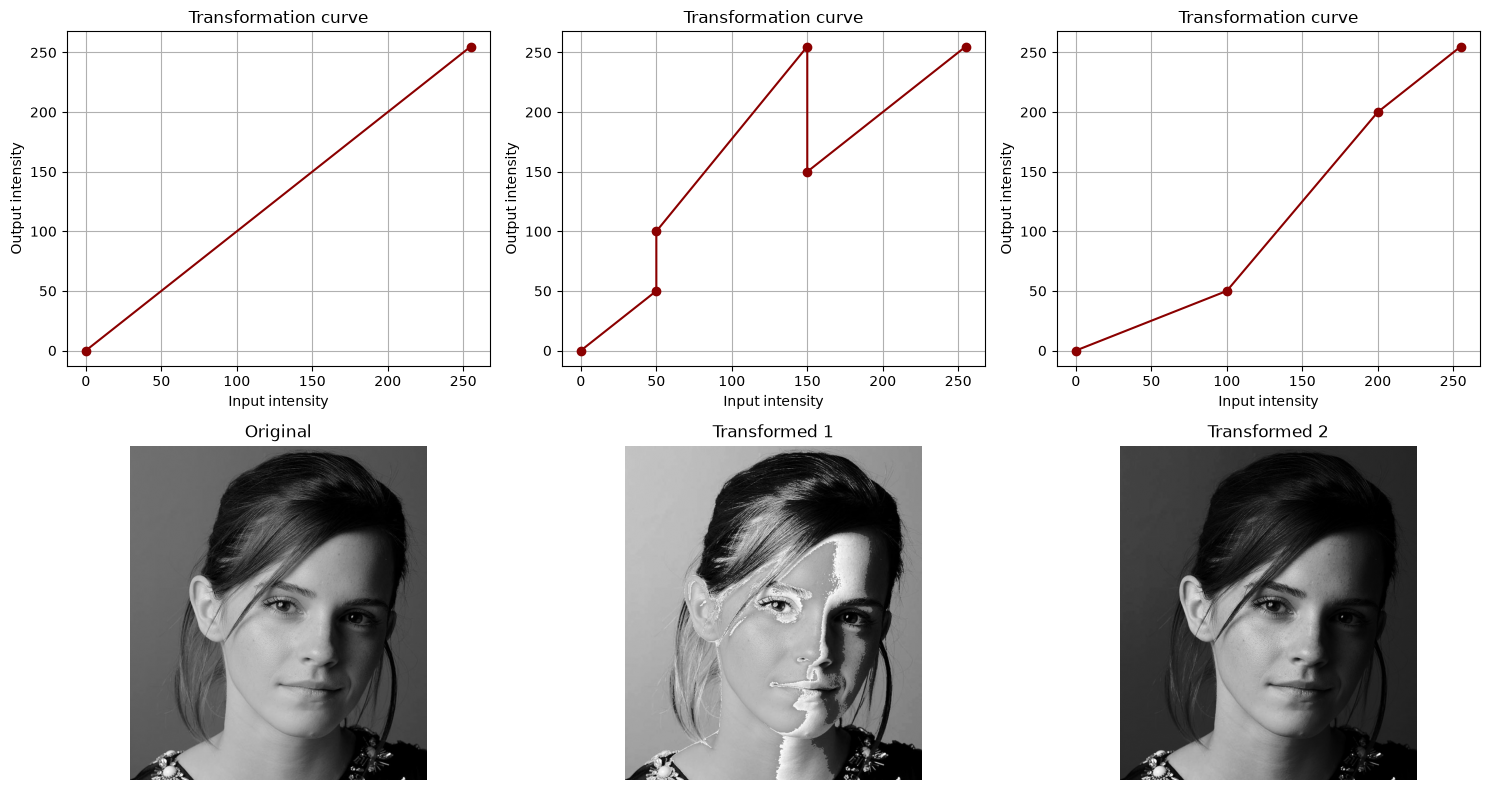

In [67]:
# Load the face image (Fig. 1b) in grayscale
img1 = cv2.imread('images/q1.jpeg', cv2.IMREAD_GRAYSCALE)
assert img1 is not None

breakpoints_original = [(0, 0), (255, 255)]


breakpoints = [(0, 0), (50, 50), (50, 100), (150, 255), (150, 150), (255, 255)]
out1, lut1 = intensity_transform(img1, breakpoints)

breakpoints2 = [(0, 0), (100, 50), (200, 200), (255, 255)]
out2, lut2 = intensity_transform(img1, breakpoints2)

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes[0, 0].plot([p[0] for p in breakpoints_original], [p[1] for p in breakpoints_original], 'o-', color='darkred')
axes[0, 0].set_xlabel('Input intensity'); axes[0, 0].set_ylabel('Output intensity')
axes[0, 0].set_title('Transformation curve'); axes[0, 0].grid(True)
axes[0, 1].plot([p[0] for p in breakpoints], [p[1] for p in breakpoints], 'o-', color='darkred')
axes[0, 1].set_xlabel('Input intensity'); axes[0, 1].set_ylabel('Output intensity')
axes[0, 1].set_title('Transformation curve'); axes[0, 1].grid(True)
axes[0, 2].plot([p[0] for p in breakpoints2], [p[1] for p in breakpoints2], 'o-', color='darkred')
axes[0, 2].set_xlabel('Input intensity'); axes[0, 2].set_ylabel('Output intensity')
axes[0, 2].set_title('Transformation curve'); axes[0, 2].grid(True)
axes[1, 0].imshow(img1, cmap='gray'); axes[1, 0].set_title('Original'); axes[1, 0].axis('off')
axes[1, 1].imshow(out1, cmap='gray'); axes[1, 1].set_title('Transformed 1'); axes[1, 1].axis('off')
axes[1, 2].imshow(out2, cmap='gray'); axes[1, 2].set_title('Transformed 2'); axes[1, 2].axis('off')

plt.tight_layout(); plt.show()


## Question 2 — Accentuating White Matter / Gray Matter in an MRI Slice

White matter is brighter than gray matter in a proton-density MRI. We design two
different piecewise-linear curves that **stretch** the intensity range corresponding
to white matter (higher intensities) or gray matter (mid intensities), while compressing
the rest. Inspect the histogram of `brain.png` first to pick sensible breakpoints.


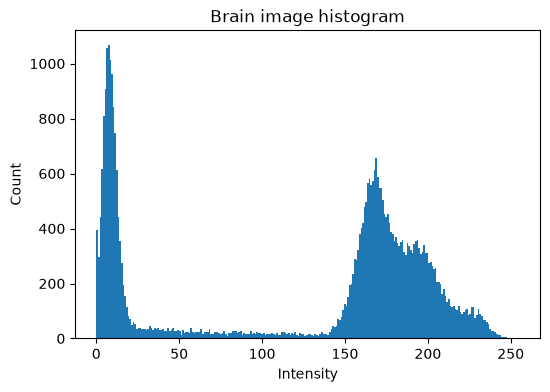

In [15]:
img2 = cv2.imread('images/q2.jpeg', cv2.IMREAD_GRAYSCALE)
assert img2 is not None

# Look at the histogram first to choose good breakpoints
plt.figure(figsize=(6,4))
plt.hist(img2.ravel(), bins=256, range=(0,255))
plt.title('Brain image histogram'); plt.xlabel('Intensity'); plt.ylabel('Count')
plt.show()


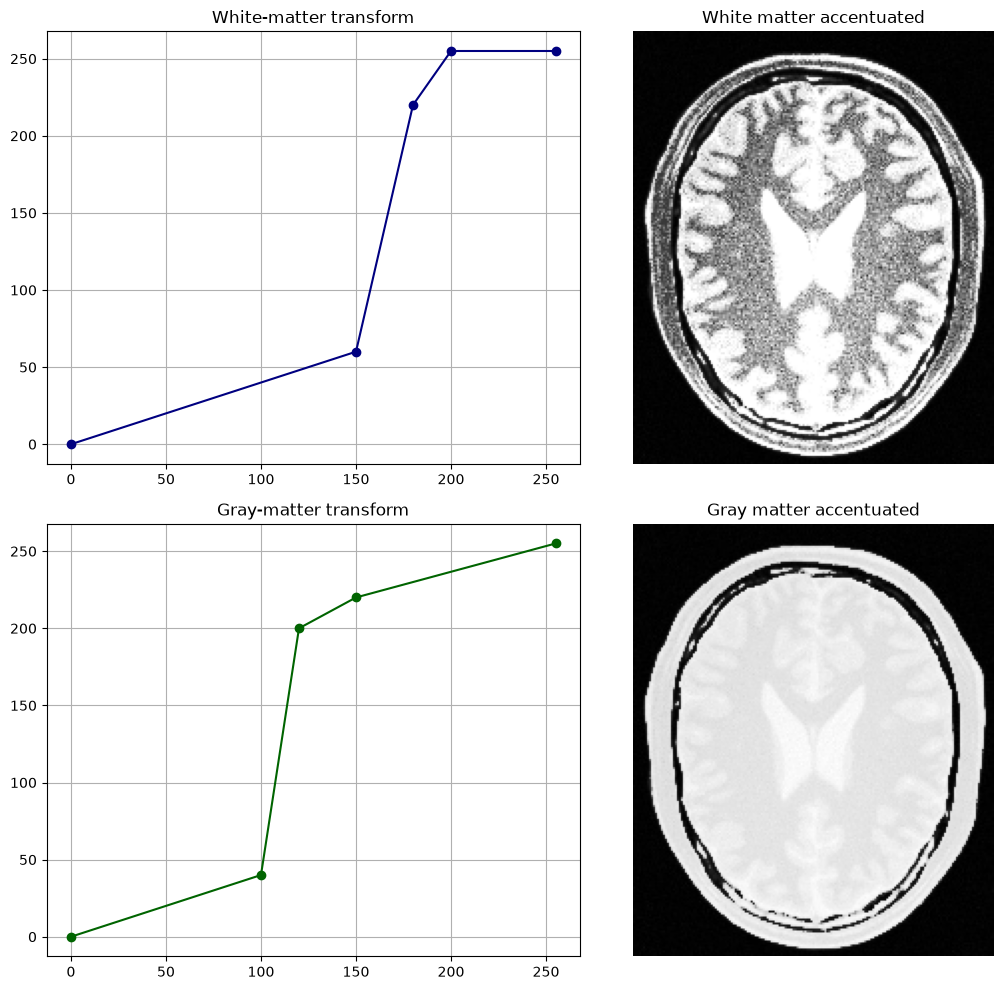

In [16]:
# (a) Accentuate WHITE MATTER: stretch the high-intensity band, compress everything else
white_matter_bp = [(0, 0), (150, 60), (180, 220), (200, 255), (255, 255)]
out_white, lut_white = intensity_transform(img2, white_matter_bp)

# (b) Accentuate GRAY MATTER: stretch the mid-intensity band instead
gray_matter_bp = [(0, 0), (100, 40), (120, 200), (150, 220), (255, 255)]
out_gray, lut_gray = intensity_transform(img2, gray_matter_bp)

fig, axes = plt.subplots(2, 2, figsize=(11, 10))
axes[0,0].plot(*zip(*white_matter_bp), 'o-', color='navy'); axes[0,0].set_title('White-matter transform'); axes[0,0].grid(True)
axes[0,1].imshow(out_white, cmap='gray'); axes[0,1].set_title('White matter accentuated'); axes[0,1].axis('off')
axes[1,0].plot(*zip(*gray_matter_bp), 'o-', color='darkgreen'); axes[1,0].set_title('Gray-matter transform'); axes[1,0].grid(True)
axes[1,1].imshow(out_gray, cmap='gray'); axes[1,1].set_title('Gray matter accentuated'); axes[1,1].axis('off')
plt.tight_layout(); plt.show()


## Question 3 — Gamma Correction on the L Plane (L\*a\*b\* space)

We convert the BGR image to `Lab`, apply gamma correction only to the **L** channel
(`L' = 255 * (L/255)^gamma`), then convert back. Gamma < 1 brightens shadows
(recovers detail from underexposed areas); gamma > 1 darkens/increases contrast.


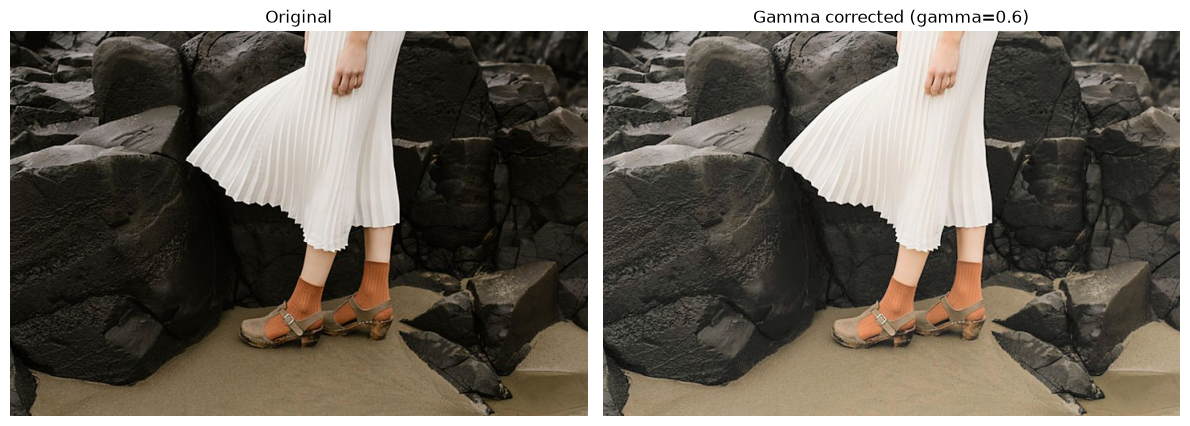

In [17]:
img3 = cv2.imread('images/q3.jpeg')  
assert img3 is not None

lab = cv2.cvtColor(img3, cv2.COLOR_BGR2LAB)
L, a, b = cv2.split(lab)

gamma = 0.6   # < 1 brightens shadows; report this value in your write-up
L_norm = L.astype(np.float32) / 255.0
L_gamma = np.power(L_norm, gamma) * 255.0
L_gamma = np.clip(L_gamma, 0, 255).astype(np.uint8)

lab_corrected = cv2.merge([L_gamma, a, b])
img3_corrected = cv2.cvtColor(lab_corrected, cv2.COLOR_LAB2BGR)

show_images([img3, img3_corrected], ['Original', f'Gamma corrected (gamma={gamma})'])


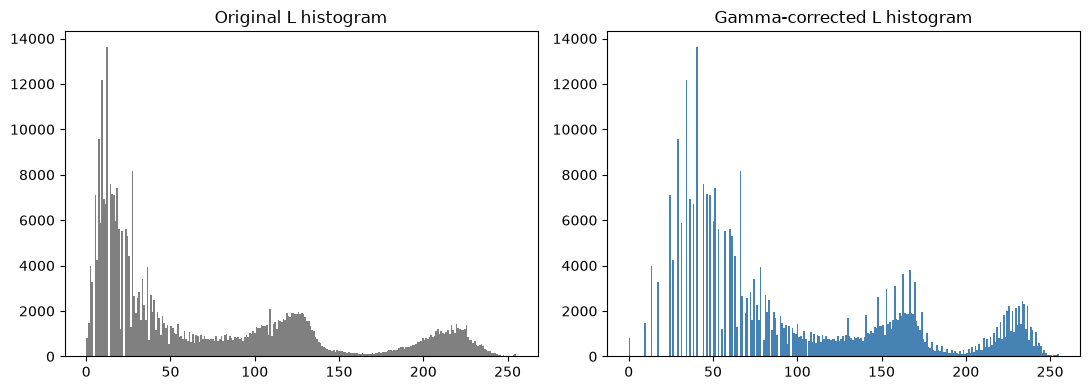

In [18]:
# Histograms before/after (on the L channel, since that's what we changed)
fig, axes = plt.subplots(1, 2, figsize=(11,4))
axes[0].hist(L.ravel(), bins=256, range=(0,255), color='gray')
axes[0].set_title('Original L histogram')
axes[1].hist(L_gamma.ravel(), bins=256, range=(0,255), color='steelblue')
axes[1].set_title('Gamma-corrected L histogram')
plt.tight_layout(); plt.show()


## Question 4 — Vibrance Enhancement via the Saturation Plane

We split the image into H, S, V (HSV space), apply
`f(x) = min(x + a*128*exp(-(x-128)^2/(2*sigma^2)), 255)` to the **S** plane only
(this boosts *mid*-saturation pixels the most, leaving already-vivid or already-gray
pixels mostly alone — a classic "vibrance" trick as opposed to a flat saturation boost),
then recombine and convert back to BGR.


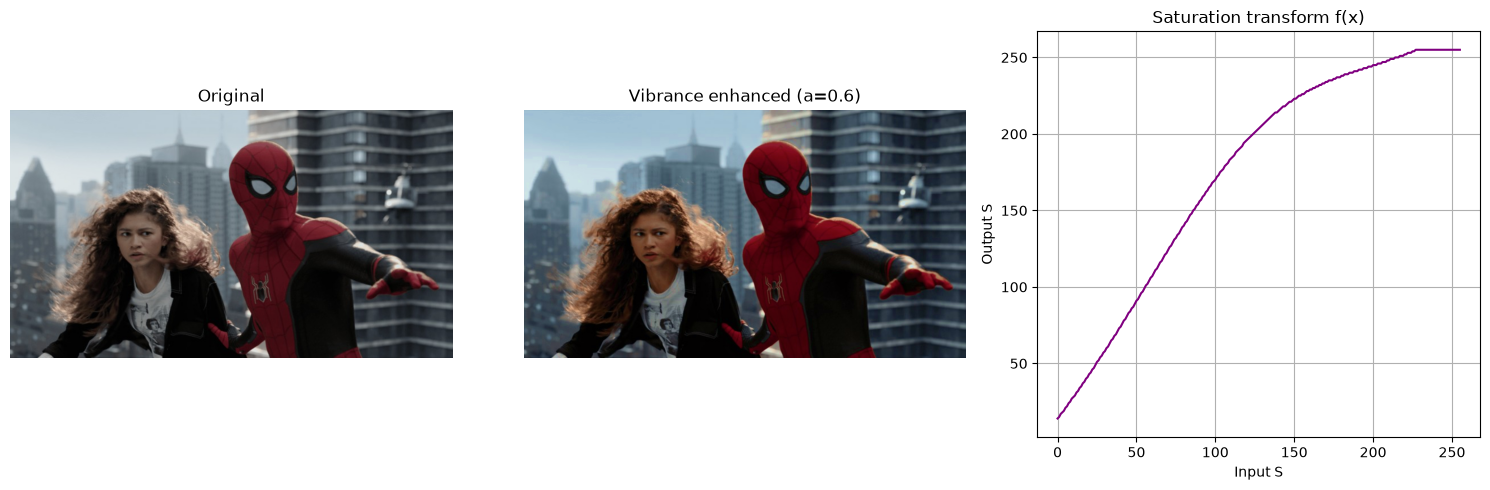

In [19]:
img4 = cv2.imread('images/q4.jpeg')
assert img4 is not None

hsv = cv2.cvtColor(img4, cv2.COLOR_BGR2HSV)
H, S, V = cv2.split(hsv)

def vibrance_lut(a, sigma=70):
    x = np.arange(256, dtype=np.float32)
    f = x + a * 128 * np.exp(-((x - 128) ** 2) / (2 * sigma ** 2))
    f = np.clip(f, 0, 255)
    return f.astype(np.uint8)

a = 0.6   # in [0,1] -- adjust and report the value you settle on
sigma = 70
lut_vibrance = vibrance_lut(a, sigma)

S_new = cv2.LUT(S, lut_vibrance)
hsv_new = cv2.merge([H, S_new, V])
img4_vibrant = cv2.cvtColor(hsv_new, cv2.COLOR_HSV2BGR)

fig, axes = plt.subplots(1, 3, figsize=(15,5))
axes[0].imshow(cv2.cvtColor(img4, cv2.COLOR_BGR2RGB)); axes[0].set_title('Original'); axes[0].axis('off')
axes[1].imshow(cv2.cvtColor(img4_vibrant, cv2.COLOR_BGR2RGB)); axes[1].set_title(f'Vibrance enhanced (a={a})'); axes[1].axis('off')
axes[2].plot(np.arange(256), lut_vibrance, color='purple')
axes[2].set_title('Saturation transform f(x)'); axes[2].set_xlabel('Input S'); axes[2].set_ylabel('Output S'); axes[2].grid(True)
plt.tight_layout(); plt.show()


## Question 5 — Histogram Equalization (written from scratch)

Classic histogram equalization: build the histogram, compute the CDF, normalize the
CDF to `[0,255]`, and use that as a LUT.


[ WARN:0@1827.739] global grfmt_tiff.cpp:123 TIFF_Warning TIFFFetchNormalTag: ASCII value for tag "ImageDescription" does not end in null byte. Forcing it to be null


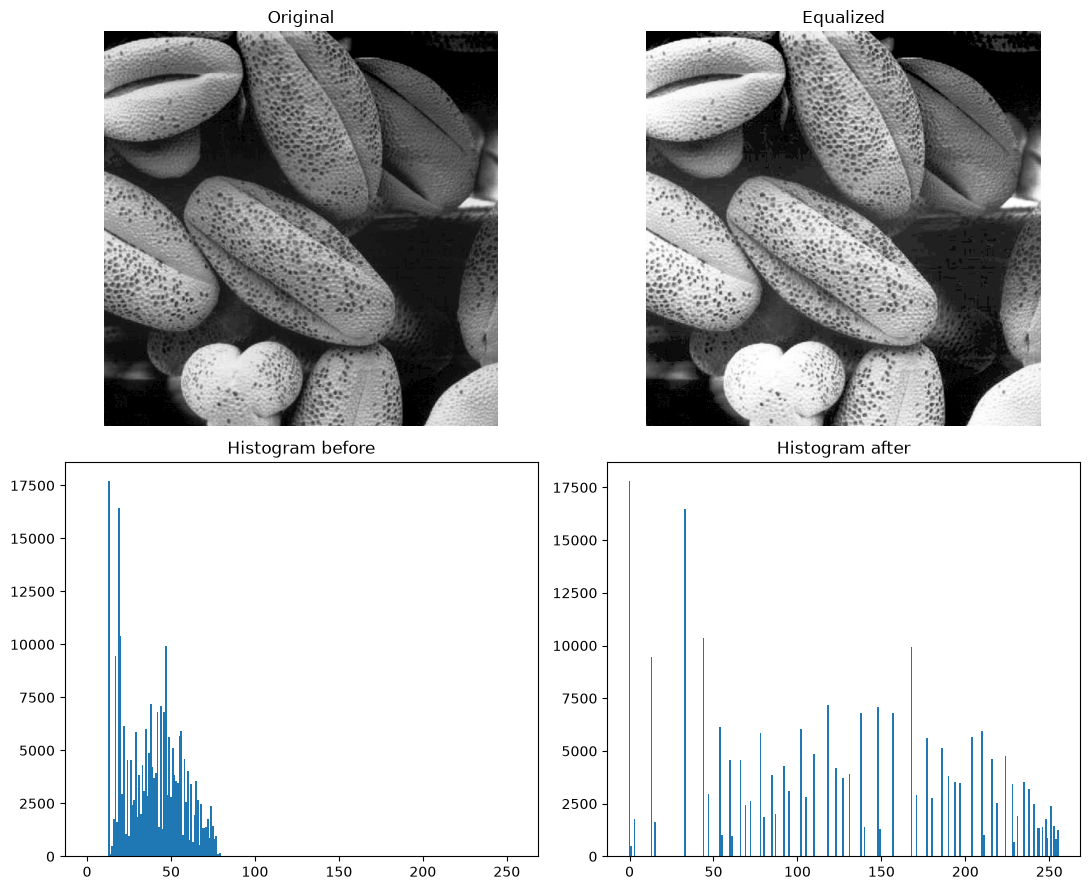

In [20]:
def my_hist_equalize(im):
    """im: grayscale uint8 image"""
    hist, _ = np.histogram(im.ravel(), bins=256, range=(0, 256))
    cdf = np.cumsum(hist)
    cdf_min = cdf[cdf > 0].min()
    total = im.size
    lut = np.round((cdf - cdf_min) / (total - cdf_min) * 255).clip(0, 255).astype(np.uint8)
    return cv2.LUT(im, lut), hist, lut

img5 = cv2.imread('images/q5.jpeg', cv2.IMREAD_GRAYSCALE)
assert img5 is not None

eq5, hist_before, lut5 = my_hist_equalize(img5)
hist_after, _ = np.histogram(eq5.ravel(), bins=256, range=(0,256))

fig, axes = plt.subplots(2, 2, figsize=(11,9))
axes[0,0].imshow(img5, cmap='gray'); axes[0,0].set_title('Original'); axes[0,0].axis('off')
axes[0,1].imshow(eq5, cmap='gray'); axes[0,1].set_title('Equalized'); axes[0,1].axis('off')
axes[1,0].bar(range(256), hist_before, width=1); axes[1,0].set_title('Histogram before')
axes[1,1].bar(range(256), hist_after, width=1); axes[1,1].set_title('Histogram after')
plt.tight_layout(); plt.show()


## Question 6 — Histogram Equalization on the Foreground Only

Steps: split HSV -> threshold a suitable plane to build a binary mask -> mask out
the foreground with `cv2.bitwise_and` -> histogram-equalize the foreground pixels only
(using the CDF formula) -> recombine with the untouched background.


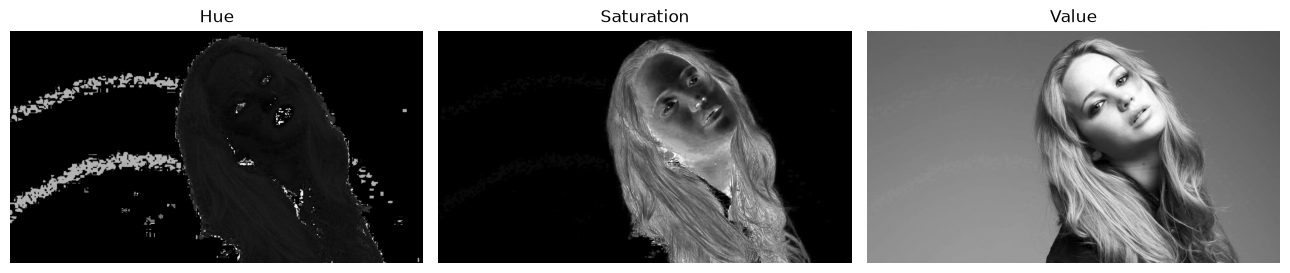

In [21]:
img6 = cv2.imread('images/q6.jpeg')
assert img6 is not None

hsv6 = cv2.cvtColor(img6, cv2.COLOR_BGR2HSV)
H6, S6, V6 = cv2.split(hsv6)

fig, axes = plt.subplots(1, 3, figsize=(13,4))
axes[0].imshow(H6, cmap='gray'); axes[0].set_title('Hue'); axes[0].axis('off')
axes[1].imshow(S6, cmap='gray'); axes[1].set_title('Saturation'); axes[1].axis('off')
axes[2].imshow(V6, cmap='gray'); axes[2].set_title('Value'); axes[2].axis('off')
plt.tight_layout(); plt.show()


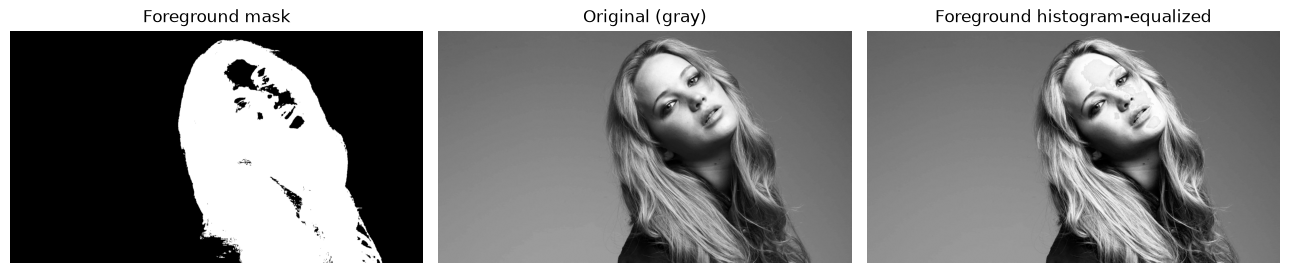

In [22]:
# (b) Threshold a suitable plane (Saturation often separates a person/subject
#     from a plain background well -- inspect the planes above and adjust the threshold)
_, mask = cv2.threshold(S6, 40, 255, cv2.THRESH_BINARY)
mask = mask.astype(np.uint8)

# (c) Foreground only
gray6 = cv2.cvtColor(img6, cv2.COLOR_BGR2GRAY)
foreground = cv2.bitwise_and(gray6, gray6, mask=mask)
hist_fg = cv2.calcHist([gray6], [0], mask, [256], [0, 256]).ravel()

# (d) cumulative sum of the foreground histogram
cdf_fg = np.cumsum(hist_fg)

# (e) equalize using the standard formula, but ignoring background (0-count) contribution
cdf_min = cdf_fg[cdf_fg > 0].min()
n_fg_pixels = cdf_fg[-1]
lut_fg = np.round((cdf_fg - cdf_min) / (n_fg_pixels - cdf_min) * 255).clip(0, 255).astype(np.uint8)
fg_equalized = cv2.LUT(gray6, lut_fg)
fg_equalized = cv2.bitwise_and(fg_equalized, fg_equalized, mask=mask)

# (f) background + equalized foreground
inv_mask = cv2.bitwise_not(mask)
background = cv2.bitwise_and(gray6, gray6, mask=inv_mask)
result6 = cv2.add(background, fg_equalized)

fig, axes = plt.subplots(1, 3, figsize=(13,4))
axes[0].imshow(mask, cmap='gray'); axes[0].set_title('Foreground mask'); axes[0].axis('off')
axes[1].imshow(gray6, cmap='gray'); axes[1].set_title('Original (gray)'); axes[1].axis('off')
axes[2].imshow(result6, cmap='gray'); axes[2].set_title('Foreground histogram-equalized'); axes[2].axis('off')
plt.tight_layout(); plt.show()


## Question 7 — Sobel Filtering (3 ways)

(a) `cv2.filter2D` with the full 3x3 Sobel kernel.

(b) A manual, from-scratch convolution.

(c) Using the separability property: Sobel = column vector `[1,2,1]^T` convolved with
row vector `[1,0,-1]` (vertical smoothing then horizontal differencing).


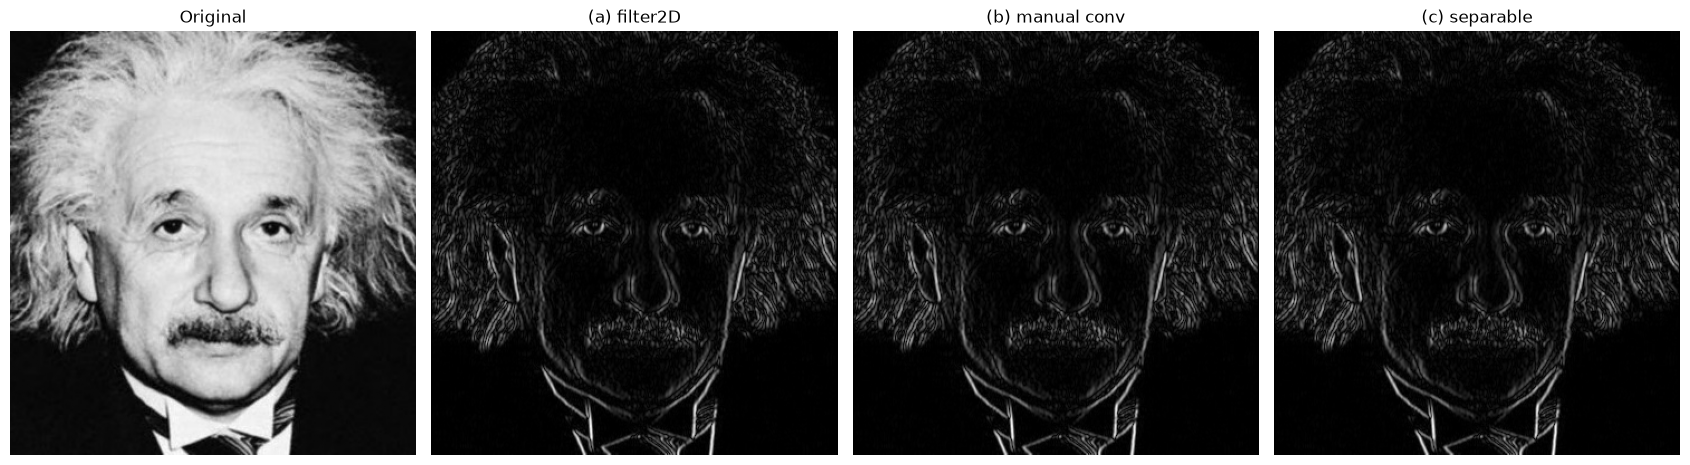

Max abs difference (a vs b): 0.0
Max abs difference (a vs c): 0.0


In [23]:
img7 = cv2.imread('images/q7.jpeg', cv2.IMREAD_GRAYSCALE)
assert img7 is not None

sobel_x_kernel = np.array([[1, 0, -1],
                            [2, 0, -2],
                            [1, 0, -1]], dtype=np.float32)

# (a) Using filter2D
sobel_a = cv2.filter2D(img7.astype(np.float32), -1, sobel_x_kernel)

# (b) Manual convolution (naive double loop -- slow but explicit)
def manual_conv2d(im, kernel):
    im = im.astype(np.float32)
    kh, kw = kernel.shape
    pad_h, pad_w = kh // 2, kw // 2
    padded = np.pad(im, ((pad_h, pad_h), (pad_w, pad_w)), mode='reflect')
    out = np.zeros_like(im)
    # flip kernel for true convolution (filter2D does correlation by default,
    # so flip if you want to match cv2.filter2D exactly -- Sobel is symmetric-ish so it matters on the sign)
    k = kernel  # using correlation to match cv2.filter2D's default behaviour
    for i in range(im.shape[0]):
        for j in range(im.shape[1]):
            region = padded[i:i+kh, j:j+kw]
            out[i, j] = np.sum(region * k)
    return out

sobel_b = manual_conv2d(img7, sobel_x_kernel)

# (c) Separable filtering: [1,2,1]^T * [1,0,-1]
col = np.array([[1], [2], [1]], dtype=np.float32)
row = np.array([[1, 0, -1]], dtype=np.float32)
temp = cv2.filter2D(img7.astype(np.float32), -1, col)   # vertical smoothing
sobel_c = cv2.filter2D(temp, -1, row)                     # horizontal differencing

fig, axes = plt.subplots(1, 4, figsize=(17,5))
axes[0].imshow(img7, cmap='gray'); axes[0].set_title('Original'); axes[0].axis('off')
axes[1].imshow(np.abs(sobel_a), cmap='gray'); axes[1].set_title('(a) filter2D'); axes[1].axis('off')
axes[2].imshow(np.abs(sobel_b), cmap='gray'); axes[2].set_title('(b) manual conv'); axes[2].axis('off')
axes[3].imshow(np.abs(sobel_c), cmap='gray'); axes[3].set_title('(c) separable'); axes[3].axis('off')
plt.tight_layout(); plt.show()

print('Max abs difference (a vs b):', np.max(np.abs(sobel_a - sobel_b)))
print('Max abs difference (a vs c):', np.max(np.abs(sobel_a - sobel_c)))


## Question 8 — Image Zoom (Nearest-Neighbor & Bilinear) + SSD Evaluation

We implement our own `zoom_image(im, s, method)` (not `cv2.resize`) for factor
`s in (0,10]`, then scale the provided *small* images up by 4x and compare against the
*large* originals using normalized SSD.


In [26]:
def zoom_image(im, s, method='bilinear'):
    """
    im: HxW or HxWxC uint8 image
    s: zoom factor in (0, 10]
    method: 'nearest' or 'bilinear'
    """
    assert 0 < s <= 10
    h, w = im.shape[:2]
    new_h, new_w = max(1, int(round(h * s))), max(1, int(round(w * s)))
    im_f = im.astype(np.float32)

    # coordinates in the source image for every output pixel
    y_out, x_out = np.meshgrid(np.arange(new_h), np.arange(new_w), indexing='ij')
    src_y = (y_out + 0.5) / s - 0.5
    src_x = (x_out + 0.5) / s - 0.5

    if method == 'nearest':
        sy = np.clip(np.round(src_y).astype(int), 0, h - 1)
        sx = np.clip(np.round(src_x).astype(int), 0, w - 1)
        out = im_f[sy, sx]

    elif method == 'bilinear':
        y0 = np.clip(np.floor(src_y).astype(int), 0, h - 1)
        x0 = np.clip(np.floor(src_x).astype(int), 0, w - 1)
        y1 = np.clip(y0 + 1, 0, h - 1)
        x1 = np.clip(x0 + 1, 0, w - 1)

        wy = np.clip(src_y - y0, 0, 1)
        wx = np.clip(src_x - x0, 0, 1)

        if im_f.ndim == 3:
            wy = wy[..., None]; wx = wx[..., None]

        top = im_f[y0, x0] * (1 - wx) + im_f[y0, x1] * wx
        bottom = im_f[y1, x0] * (1 - wx) + im_f[y1, x1] * wx
        out = top * (1 - wy) + bottom * wy
    else:
        raise ValueError("method must be 'nearest' or 'bilinear'")

    return np.clip(out, 0, 255).astype(np.uint8)


def normalized_ssd(im1, im2):
    """Normalized sum of squared differences between two same-size images."""
    a = im1.astype(np.float32); b = im2.astype(np.float32)
    return np.sum((a - b) ** 2) / (a.size * (255.0 ** 2))


In [27]:
# Test: scale up the provided small images by 4x and compare with the large originals
pairs = [
    ('images/small1.png', 'images/large1.png'),
    ('images/small2.png', 'images/large2.png'),
]

for small_path, large_path in pairs:
    small = cv2.imread(small_path)
    large = cv2.imread(large_path)
    if small is None or large is None:
        print(f'Skipping {small_path} / {large_path} -- file not found, add the provided course images here')
        continue

    up_nn = zoom_image(small, 4, method='nearest')
    up_bl = zoom_image(small, 4, method='bilinear')

    # crop/pad to exactly match the large image's shape before comparing
    h, w = large.shape[:2]
    up_nn = up_nn[:h, :w]
    up_bl = up_bl[:h, :w]

    ssd_nn = normalized_ssd(up_nn, large)
    ssd_bl = normalized_ssd(up_bl, large)
    print(f'{small_path}: normalized SSD  nearest={ssd_nn:.5f}   bilinear={ssd_bl:.5f}')

    show_images([large, up_nn, up_bl], ['Original large', 'Nearest-neighbor x4', 'Bilinear x4'])


Skipping images/small1.png / images/large1.png -- file not found, add the provided course images here
Skipping images/small2.png / images/large2.png -- file not found, add the provided course images here


[ WARN:0@5806.842] global loadsave.cpp:278 findDecoder imread_('images/small1.png'): can't open/read file: check file path/integrity
[ WARN:0@5806.842] global loadsave.cpp:278 findDecoder imread_('images/large1.png'): can't open/read file: check file path/integrity
[ WARN:0@5806.842] global loadsave.cpp:278 findDecoder imread_('images/small2.png'): can't open/read file: check file path/integrity
[ WARN:0@5806.842] global loadsave.cpp:278 findDecoder imread_('images/large2.png'): can't open/read file: check file path/integrity


## Question 9 — GrabCut Segmentation + Background Blur (Bokeh Effect)

We use `cv2.grabCut` with a rectangle around the flower to separate foreground from
background, then blur only the background heavily and recombine — simulating a
shallow depth-of-field / bokeh look.


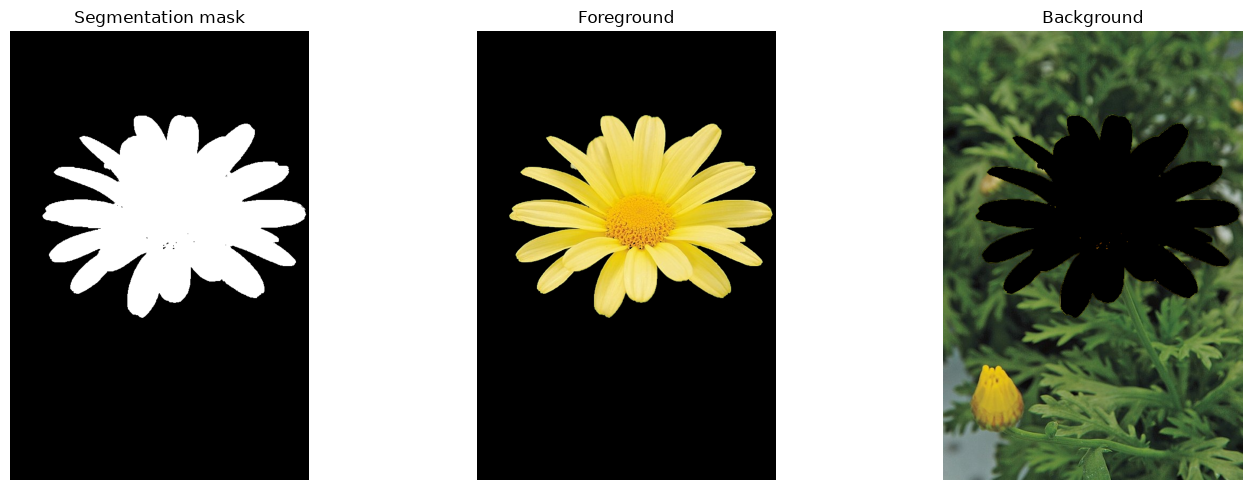

In [48]:
img9 = cv2.imread('images/q9.jpeg')
assert img9 is not None

h, w = img9.shape[:2]
mask = np.zeros((h, w), np.uint8)
bgdModel = np.zeros((1, 65), np.float64)
fgdModel = np.zeros((1, 65), np.float64)

# Rectangle roughly containing the flower 
rect = (60, 60, 600, 550)

cv2.grabCut(img9, mask, rect, bgdModel, fgdModel, 5, cv2.GC_INIT_WITH_RECT)
mask2 = np.where((mask == cv2.GC_FGD) | (mask == cv2.GC_PR_FGD), 1, 0).astype('uint8')

foreground9 = img9 * mask2[:, :, None]
background9 = img9 * (1 - mask2[:, :, None])

fig, axes = plt.subplots(1, 3, figsize=(15,5))
axes[0].imshow(mask2, cmap='gray'); axes[0].set_title('Segmentation mask'); axes[0].axis('off')
axes[1].imshow(cv2.cvtColor(foreground9, cv2.COLOR_BGR2RGB)); axes[1].set_title('Foreground'); axes[1].axis('off')
axes[2].imshow(cv2.cvtColor(background9, cv2.COLOR_BGR2RGB)); axes[2].set_title('Background'); axes[2].axis('off')
plt.tight_layout(); plt.show()


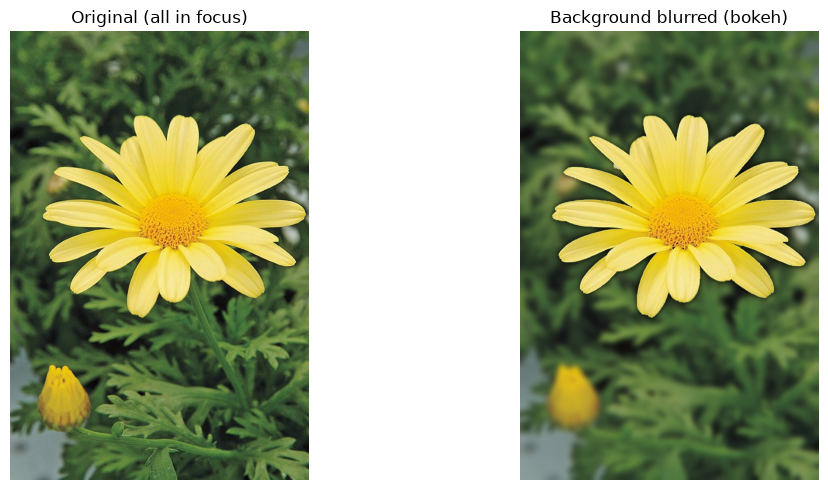

In [52]:
# (b) Blur the background heavily, keep the foreground sharp
blurred_bg = cv2.GaussianBlur(background9, (0, 0), sigmaX=5)
mask3 = mask2[:, :, None].astype(np.float32)
enhanced9 = (img9.astype(np.float32) * mask3 + blurred_bg.astype(np.float32) * (1 - mask3)).astype(np.uint8)

show_images([img9, enhanced9], ['Original (all in focus)', 'Background blurred (bokeh)'])


**(c) Why is the background just beyond the flower's edge dark?**
Because the binary mask from GrabCut is not perfectly feathered at the boundary — pixels
right at the edge are a hard mix of foreground and blurred-background values, and the
Gaussian blur of the background pulls in dark pixels *from inside the flower's silhouette*
(since that region was zeroed-out / black in `background9` before blurring), so the blur
smears black into the area just outside the flower. Using a soft/feathered mask
(e.g. blurring the mask itself before compositing) fixes this halo/dark-fringe artifact.


## Question 10 — Bilateral Filtering: OpenCV vs. From-Scratch

(a) `cv2.bilateralFilter` vs. a Gaussian blur with a comparable kernel.
(b) A from-scratch bilateral filter implementation, compared quantitatively (e.g. via
normalized SSD or PSNR) against OpenCV's version.


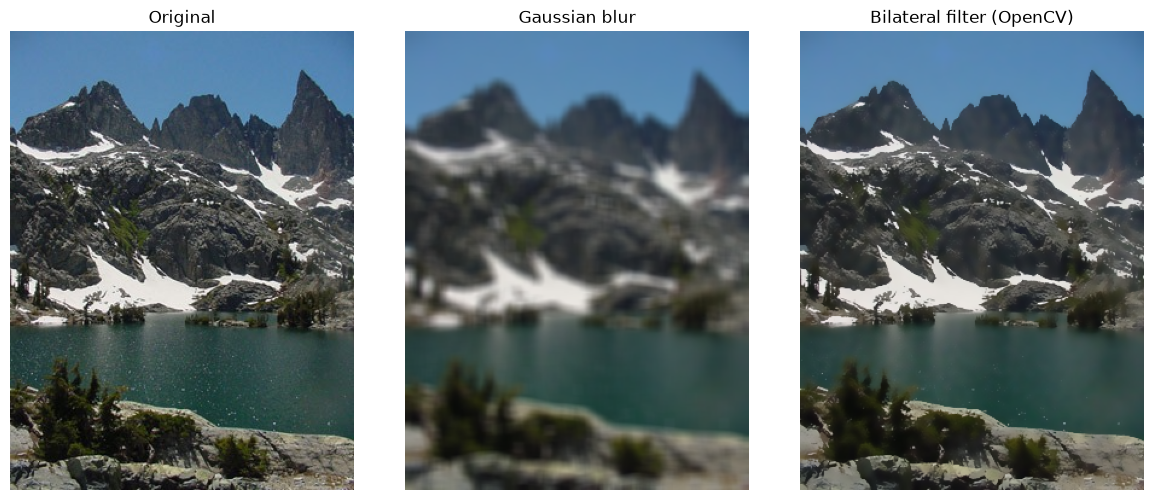

In [30]:
img10 = cv2.imread('images/q10.jpeg')
assert img10 is not None

sigma_s, sigma_r = 15, 75     # spatial and range sigmas -- tune to taste
bilateral_cv = cv2.bilateralFilter(img10, d=9, sigmaColor=sigma_r, sigmaSpace=sigma_s)
gaussian_cv = cv2.GaussianBlur(img10, (9, 9), sigmaX=sigma_s)

show_images([img10, gaussian_cv, bilateral_cv],
            ['Original', 'Gaussian blur', 'Bilateral filter (OpenCV)'])


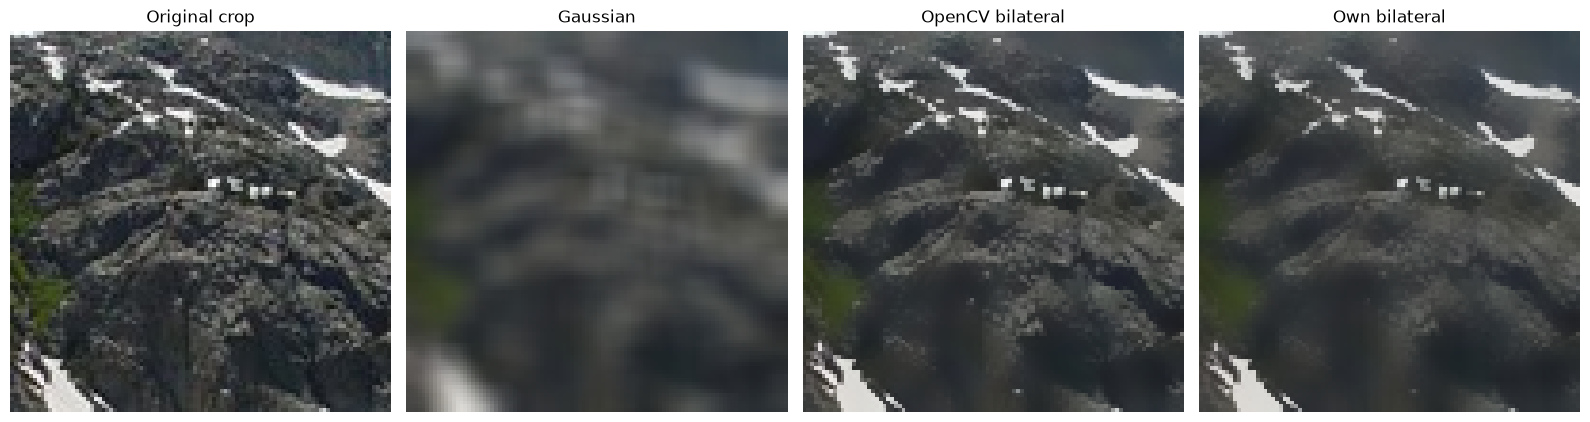

Normalized SSD between own and OpenCV bilateral filter: 0.000680


In [31]:
def my_bilateral_filter(im, d, sigma_s, sigma_r):
    """
    Own implementation of the bilateral filter.
    im: HxWxC or HxW uint8 image
    d: window diameter (must be odd), e.g. 9
    sigma_s: spatial sigma
    sigma_r: range (intensity) sigma
    """
    im_f = im.astype(np.float32)
    r = d // 2
    pad_width = ((r, r), (r, r), (0, 0)) if im_f.ndim == 3 else ((r, r), (r, r))
    padded = np.pad(im_f, pad_width, mode='reflect')

    # precompute spatial Gaussian weights (same for every pixel)
    ax = np.arange(-r, r + 1)
    xx, yy = np.meshgrid(ax, ax)
    spatial_w = np.exp(-(xx**2 + yy**2) / (2 * sigma_s**2))

    out = np.zeros_like(im_f)
    H, W = im.shape[:2]
    for i in range(H):
        for j in range(W):
            window = padded[i:i+d, j:j+d]
            center = padded[i+r, j+r]
            diff = window - center
            if im_f.ndim == 3:
                range_w = np.exp(-np.sum(diff**2, axis=2) / (2 * sigma_r**2))
            else:
                range_w = np.exp(-(diff**2) / (2 * sigma_r**2))
            weight = spatial_w * range_w
            if im_f.ndim == 3:
                weight_n = weight[..., None]
                out[i, j] = np.sum(window * weight_n, axis=(0, 1)) / np.sum(weight)
            else:
                out[i, j] = np.sum(window * weight) / np.sum(weight)
    return np.clip(out, 0, 255).astype(np.uint8)

# NOTE: the pure-Python double loop above is slow. For the report,
# run it on a small crop (e.g. 100x100) of the lake image to keep runtime reasonable.
crop = img10[100:200, 100:200]
bilateral_own = my_bilateral_filter(crop, d=9, sigma_s=sigma_s, sigma_r=sigma_r)
bilateral_cv_crop = cv2.bilateralFilter(crop, d=9, sigmaColor=sigma_r, sigmaSpace=sigma_s)
gaussian_crop = cv2.GaussianBlur(crop, (9, 9), sigmaX=sigma_s)

show_images([crop, gaussian_crop, bilateral_cv_crop, bilateral_own],
            ['Original crop', 'Gaussian', 'OpenCV bilateral', 'Own bilateral'], figsize=(16,5))

ssd_val = normalized_ssd(bilateral_own, bilateral_cv_crop)
print(f'Normalized SSD between own and OpenCV bilateral filter: {ssd_val:.6f}')


A low normalized SSD (close to 0) confirms your from-scratch implementation matches
OpenCV's closely. Discuss any remaining differences (OpenCV uses some internal
optimizations/approximations for speed) and comment on runtime: your Python loop version
will be dramatically slower than OpenCV's C++ implementation — mention this trade-off.
